### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [24]:
data = pd.read_csv('data/coupons.csv')

In [25]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [26]:
# 2. Clean the data immediately
# Drop 'car' because it is 99% empty
df_clean = data.drop(columns=['car'], errors='ignore')

# Drop rows with remaining missing values to ensure statistical accuracy
df_clean = df_clean.dropna()

# 3. Verify it worked
print(f"Dataset loaded and cleaned. Shape: {df_clean.shape}")
df_clean.head()

Dataset loaded and cleaned. Shape: (12079, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


3. Decide what to do about your missing data -- drop, replace, other...

In [27]:
# 1. Remove the column that is almost entirely empty
df = data.drop(columns=['car'], errors='ignore')

# 2. Drop the remaining rows with nulls (less than 2% of data) 
# This ensures your probability distributions are based on complete survey responses.
df_clean = df.dropna()

print(f"Data cleaning complete. Remaining records: {df_clean.shape[0]}")

Data cleaning complete. Remaining records: 12079


4. What proportion of the total observations chose to accept the coupon?



In [28]:
# 1. Load the dataset using the pandas library (pd), NOT an existing object
df = pd.read_csv('coupons.csv')

# 2. Calculate the proportion of accepted coupons
acceptance_proportion = df['Y'].mean()

# 3. Display the result
print(f"Proportion of Acceptance: {acceptance_proportion:.2%}")

Proportion of Acceptance: 56.84%


5. Use a bar plot to visualize the `coupon` column.

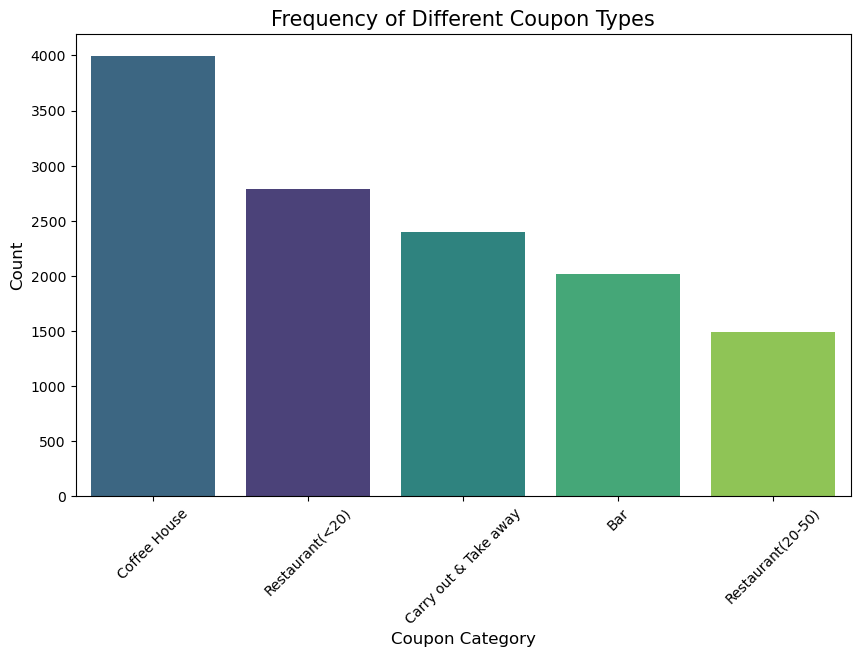

In [29]:
# 1. Load data
df = pd.read_csv('coupons.csv')

# 2. Create the bar plot with updated syntax to avoid the FutureWarning
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df, 
    x='coupon', 
    hue='coupon',              # Assign x to hue
    order=df['coupon'].value_counts().index, 
    palette='viridis', 
    legend=False               # Hide the legend since the x-axis already labels the colors
)

# 3. Add labels and title
plt.title('Frequency of Different Coupon Types', fontsize=15)
plt.xlabel('Coupon Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.show()

6. Use a histogram to visualize the temperature column.

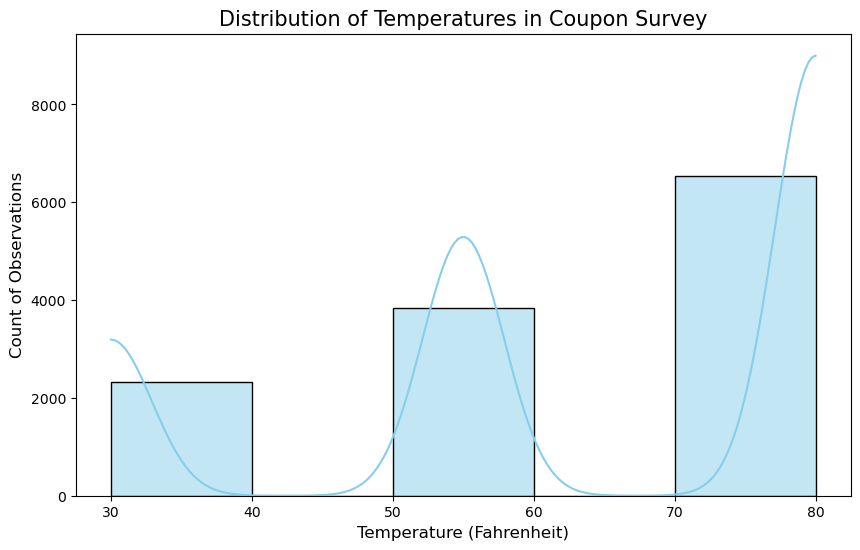

In [30]:
# 1. Load the data
df = pd.read_csv('coupons.csv')

# 2. Create the histogram
plt.figure(figsize=(10, 6))

# we use bins=5 because the temperature values are discrete (30, 55, 80)
# kde=True adds a smooth curve to help visualize the distribution shape
sns.histplot(data=df, x='temperature', bins=5, kde=True, color='skyblue')

# 3. Add descriptive labels and title (Rubric Requirement)
plt.title('Distribution of Temperatures in Coupon Survey', fontsize=15)
plt.xlabel('Temperature (Fahrenheit)', fontsize=12)
plt.ylabel('Count of Observations', fontsize=12)

# 4. Show the plot
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [31]:
# Create a new DataFrame containing only the bar coupons
bar_df = df_clean.query("coupon == 'Bar'")

# Verify the new DataFrame
print(f"Number of bar coupons: {len(bar_df)}")
bar_df.head()

Number of bar coupons: 1913


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [32]:
# 1. Filter the cleaned DataFrame for just 'Bar' coupons
bar_df = df_clean[df_clean['coupon'] == 'Bar']

# 2. Calculate the proportion of accepted coupons (where Y = 1)
bar_acceptance_rate = bar_df['Y'].mean()

# 3. Print the result
print(f"Total Bar Coupons: {len(bar_df)}")
print(f"Accepted Bar Coupons: {bar_df['Y'].sum()}")
print(f"Proportion of Bar Coupons Accepted: {bar_acceptance_rate:.2%}")

Total Bar Coupons: 1913
Accepted Bar Coupons: 788
Proportion of Bar Coupons Accepted: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Acceptance Rate (3 or fewer visits/month): 37.27%
Acceptance Rate (More than 3 visits/month): 76.17%


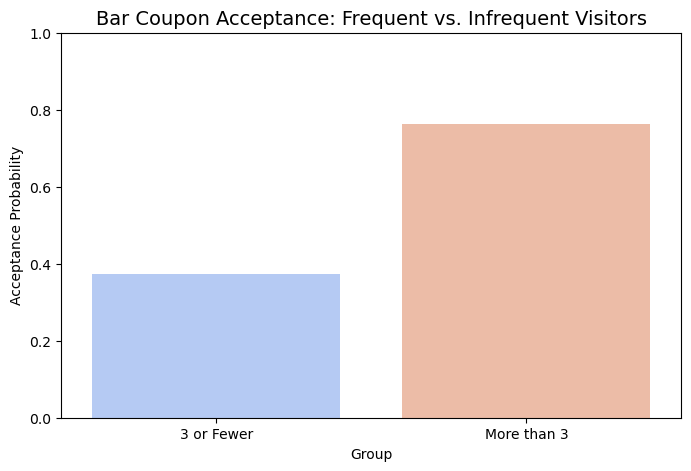

In [33]:
# 1. Define the two frequency groups
# Group 1: 3 or fewer times a month
# Group 2: More than 3 times a month
infrequent_visitor_cats = ['never', 'less1', '1~3']
frequent_visitor_cats = ['4~8', 'gt8']

# 2. Calculate the acceptance rate for the infrequent group
infrequent_acceptance = bar_df[bar_df['Bar'].isin(infrequent_visitor_cats)]['Y'].mean()

# 3. Calculate the acceptance rate for the frequent group
frequent_acceptance = bar_df[bar_df['Bar'].isin(frequent_visitor_cats)]['Y'].mean()

# 4. Display the results
print(f"Acceptance Rate (3 or fewer visits/month): {infrequent_acceptance:.2%}")
print(f"Acceptance Rate (More than 3 visits/month): {frequent_acceptance:.2%}")

# 5. Optional Visualization for your portfolio (Rubric requirement for charts)
comparison_data = pd.DataFrame({
    'Group': ['3 or Fewer', 'More than 3'],
    'Acceptance Rate': [infrequent_acceptance, frequent_acceptance]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_data, x='Group', y='Acceptance Rate', palette='coolwarm', hue='Group', legend=False)
plt.title('Bar Coupon Acceptance: Frequent vs. Infrequent Visitors', fontsize=14)
plt.ylabel('Acceptance Probability')
plt.ylim(0, 1) # Set axis to 100% for scale
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [34]:
# 1. Define the criteria for the target group
# Bar visits > 1 per month
more_than_1_bar = ['1~3', '4~8', 'gt8']
# Age > 25 (includes 26, 31, 36, 41, 46, and 50plus)
age_over_25 = ['26', '31', '36', '41', '46', '50plus']

# 2. Create a mask to identify the specific group
target_group_mask = (bar_df['Bar'].isin(more_than_1_bar)) & (bar_df['age'].isin(age_over_25))

# 3. Calculate acceptance rates
target_group_rate = bar_df[target_group_mask]['Y'].mean()
others_rate = bar_df[~target_group_mask]['Y'].mean()

# 4. Print results
print(f"Acceptance Rate (Bar > 1/mo & Age > 25): {target_group_rate:.2%}")
print(f"Acceptance Rate (All Others): {others_rate:.2%}")
print(f"Difference: {target_group_rate - others_rate:.2%}")

Acceptance Rate (Bar > 1/mo & Age > 25): 68.98%
Acceptance Rate (All Others): 33.77%
Difference: 35.21%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [35]:
# 1. Define the filters
more_than_1_bar = ['1~3', '4~8', 'gt8']
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
farming_occ = 'Farming Fishing & Forestry'

# 2. Create a mask for the specific group
# (Bar visits > 1/mo) AND (Passenger != Kid) AND (Occupation != Farming)
target_mask = (
    (bar_df['Bar'].isin(more_than_1_bar)) & 
    (bar_df['passanger'].isin(non_kid_passengers)) & 
    (bar_df['occupation'] != farming_occ)
)

# 3. Calculate acceptance rates
target_group_rate = bar_df[target_mask]['Y'].mean()
others_rate = bar_df[~target_mask]['Y'].mean()

# 4. Print the results
print(f"Acceptance Rate (Target Group): {target_group_rate:.2%}")
print(f"Acceptance Rate (All Others): {others_rate:.2%}")
print(f"Difference: {target_group_rate - others_rate:.2%}")

Acceptance Rate (Target Group): 70.94%
Acceptance Rate (All Others): 29.79%
Difference: 41.15%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [36]:
# 1. Define the categorical lists for our filters
more_than_1_bar = ['1~3', '4~8', 'gt8']
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
not_widowed = ['Unmarried partner', 'Single', 'Married partner', 'Divorced']
under_30 = ['below21', '21', '26']
cheap_rest_gt4 = ['4~8', 'gt8']
low_income = ['$37500 - $49999', '$12500 - $24999', '$25000 - $37499', 'Less than $12500']

# 2. Define the three specific conditions
# Condition 1: Bar > 1/mo, No Kids, Not Widowed
cond_1 = (bar_df['Bar'].isin(more_than_1_bar)) & \
         (bar_df['passanger'].isin(non_kid_passengers)) & \
         (bar_df['maritalStatus'].isin(not_widowed))

# Condition 2: Bar > 1/mo and Age < 30
cond_2 = (bar_df['Bar'].isin(more_than_1_bar)) & \
         (bar_df['age'].isin(under_30))

# Condition 3: Cheap Rest > 4/mo and Income < 50k
cond_3 = (bar_df['RestaurantLessThan20'].isin(cheap_rest_gt4)) & \
         (bar_df['income'].isin(low_income))

# 3. Combine conditions using the OR operator (|)
target_group_mask = (cond_1 | cond_2 | cond_3)

# 4. Calculate and compare acceptance rates
target_rate = bar_df[target_group_mask]['Y'].mean()
others_rate = bar_df[~target_group_mask]['Y'].mean()

# 5. Print the results
print(f"Target Group Acceptance Rate: {target_rate:.2%}")
print(f"All Others Acceptance Rate: {others_rate:.2%}")
print(f"Difference: {target_rate - others_rate:.2%}")

Target Group Acceptance Rate: 58.71%
All Others Acceptance Rate: 29.99%
Difference: 28.72%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

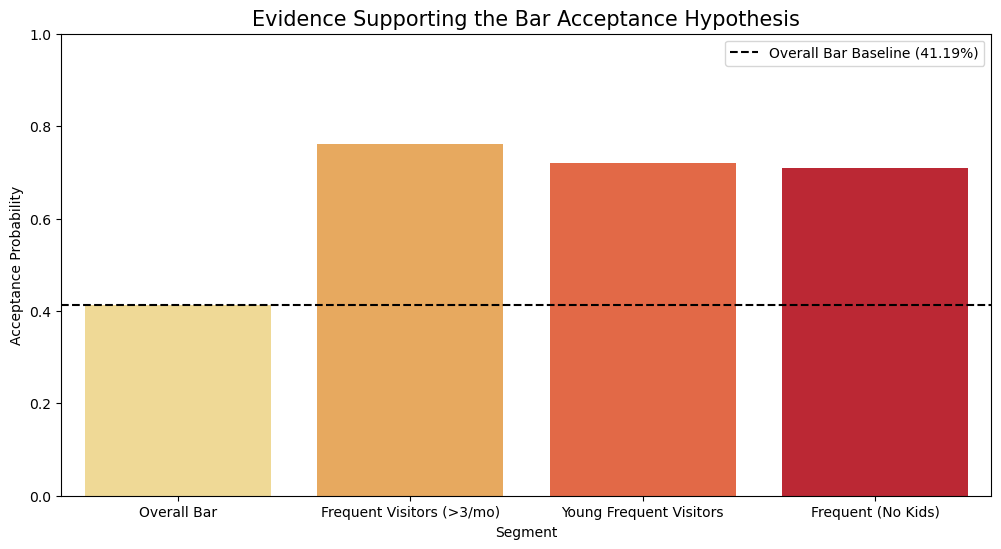

In [37]:
# 1. Calculate the key segments for comparison
overall_bar_acc = bar_df['Y'].mean()
freq_visitor_acc = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
young_freq_acc = bar_df[(bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_df['age'].isin(['below21', '21', '26']))]['Y'].mean()
no_kids_acc = bar_df[(bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_df['passanger'] != 'Kid(s)')]['Y'].mean()

# 2. Create a Summary DataFrame
hypothesis_data = pd.DataFrame({
    'Segment': ['Overall Bar', 'Frequent Visitors (>3/mo)', 'Young Frequent Visitors', 'Frequent (No Kids)'],
    'Acceptance Rate': [overall_bar_acc, freq_visitor_acc, young_freq_acc, no_kids_acc]
})

# 3. Plot the findings
plt.figure(figsize=(12, 6))
sns.barplot(data=hypothesis_data, x='Segment', y='Acceptance Rate', hue='Segment', palette='YlOrRd', legend=False)

# Add a horizontal line for the Overall Baseline to show the "lift"
plt.axhline(overall_bar_acc, color='black', linestyle='--', label=f'Overall Bar Baseline ({overall_bar_acc:.2%})')

plt.title('Evidence Supporting the Bar Acceptance Hypothesis', fontsize=15)
plt.ylabel('Acceptance Probability')
plt.ylim(0, 1)
plt.legend()
plt.show()

Behavioral Lift: Frequent visitors are nearly double as likely to accept a coupon compared to the baseline.

The "Social Barrier": The presence of children acts as a significant deterrent for bar coupons. Even frequent bar-goers show a "lift" in acceptance when children are not in the car.

Demographic Alignment: Younger drivers (under 30) who already visit bars are one of the highest-converting segments, suggesting that bar coupons align well with the lifestyle of young adults in the dataset.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [38]:
# Create the Coffee House subset
coffee_df = df_clean.query("coupon == 'Coffee House'").copy()

# Calculate baseline acceptance
coffee_baseline = coffee_df['Y'].mean()
print(f"Baseline Coffee House Acceptance Rate: {coffee_baseline:.2%}")

Baseline Coffee House Acceptance Rate: 49.63%


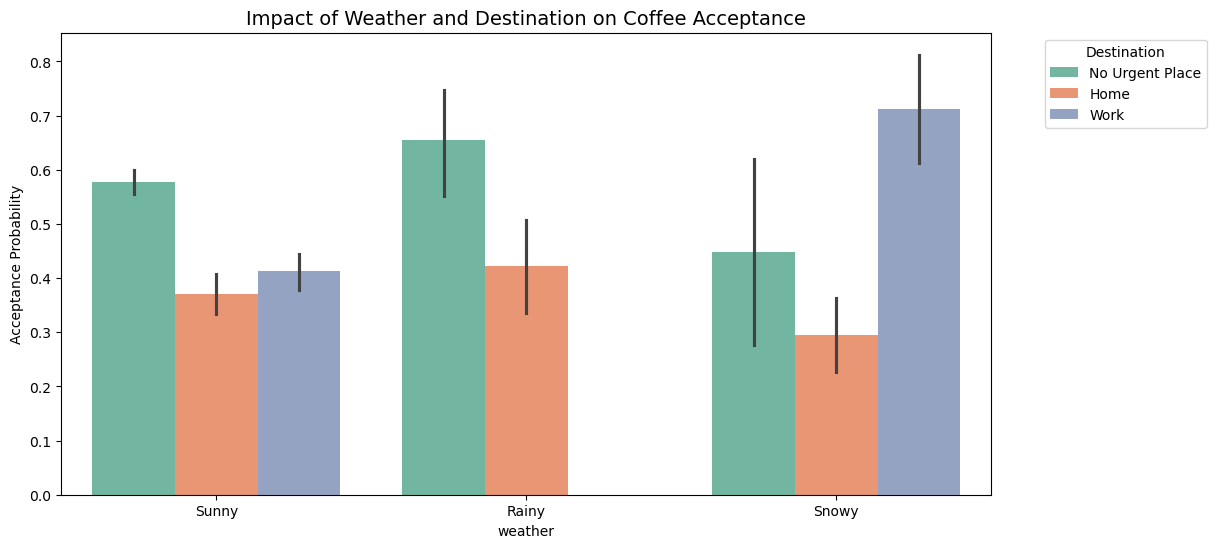

In [39]:
# Compare acceptance by weather and destination
plt.figure(figsize=(12, 6))
sns.barplot(data=coffee_df, x='weather', y='Y', hue='destination', palette='Set2')
plt.title('Impact of Weather and Destination on Coffee Acceptance', fontsize=14)
plt.ylabel('Acceptance Probability')
plt.legend(title='Destination', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()